### Source: https://arxiv.org/html/2411.18261v1

### Dynamiczne ustalanie cen detalicznych z wykorzystaniem uczenia ze wzmocnieniem - Deep Q Network (DQN)

Reinforcement Learning (RL) został zidentyfikowany jako alternatywa dla tradycyjnych modeli ze względu na jego zdolność adaptacji i ciągłego uczenia się.

Metodologia zastosowana do wdrożenia i oceny dynamicznego modelu cenowego opartego na uczeniu ze wzmocnieniem, ze szczególnym uwzględnieniem branży detalicznej. Wykorzystujemy algorytm Q-Learning do optymalizacji cen w środowisku, które odzwierciedla realistyczną dynamikę rynku i zachowania konsumentów.

Aby skutecznie symulować dynamiczne scenariusze cenowe, stworzyliśmy środowisko cenowe. Środowisko to obejmuje różne czynniki, takie jak popyt bazowy, cena bazowa, elastyczność cenowa, sezonowość i koszty. Parametry te mają kluczowe znaczenie, ponieważ bezpośrednio wpływają na skuteczność strategii cenowej w odpowiedzi na popyt rynkowy.

Parametry modelu danych

- Popyt bazowy: Szacowana liczba sprzedanych jednostek produktu.

- Cena bazowa: Cena początkowa ustalona na podstawie danych historycznych i analizy rynku.

- Elastyczność: Mierzy wrażliwość popytu produktu na zmiany ceny.

- Czynnik sezonowy: Sezonowa zmiana popytu.

- Koszty: Koszty zmienne i stałe związane z produkcją.

Funckja popytu

Popyt = Popyt bazowy × Współczynnik sezonowy + (Cena bazowa / Cena)^Elastyczność

### Generowanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

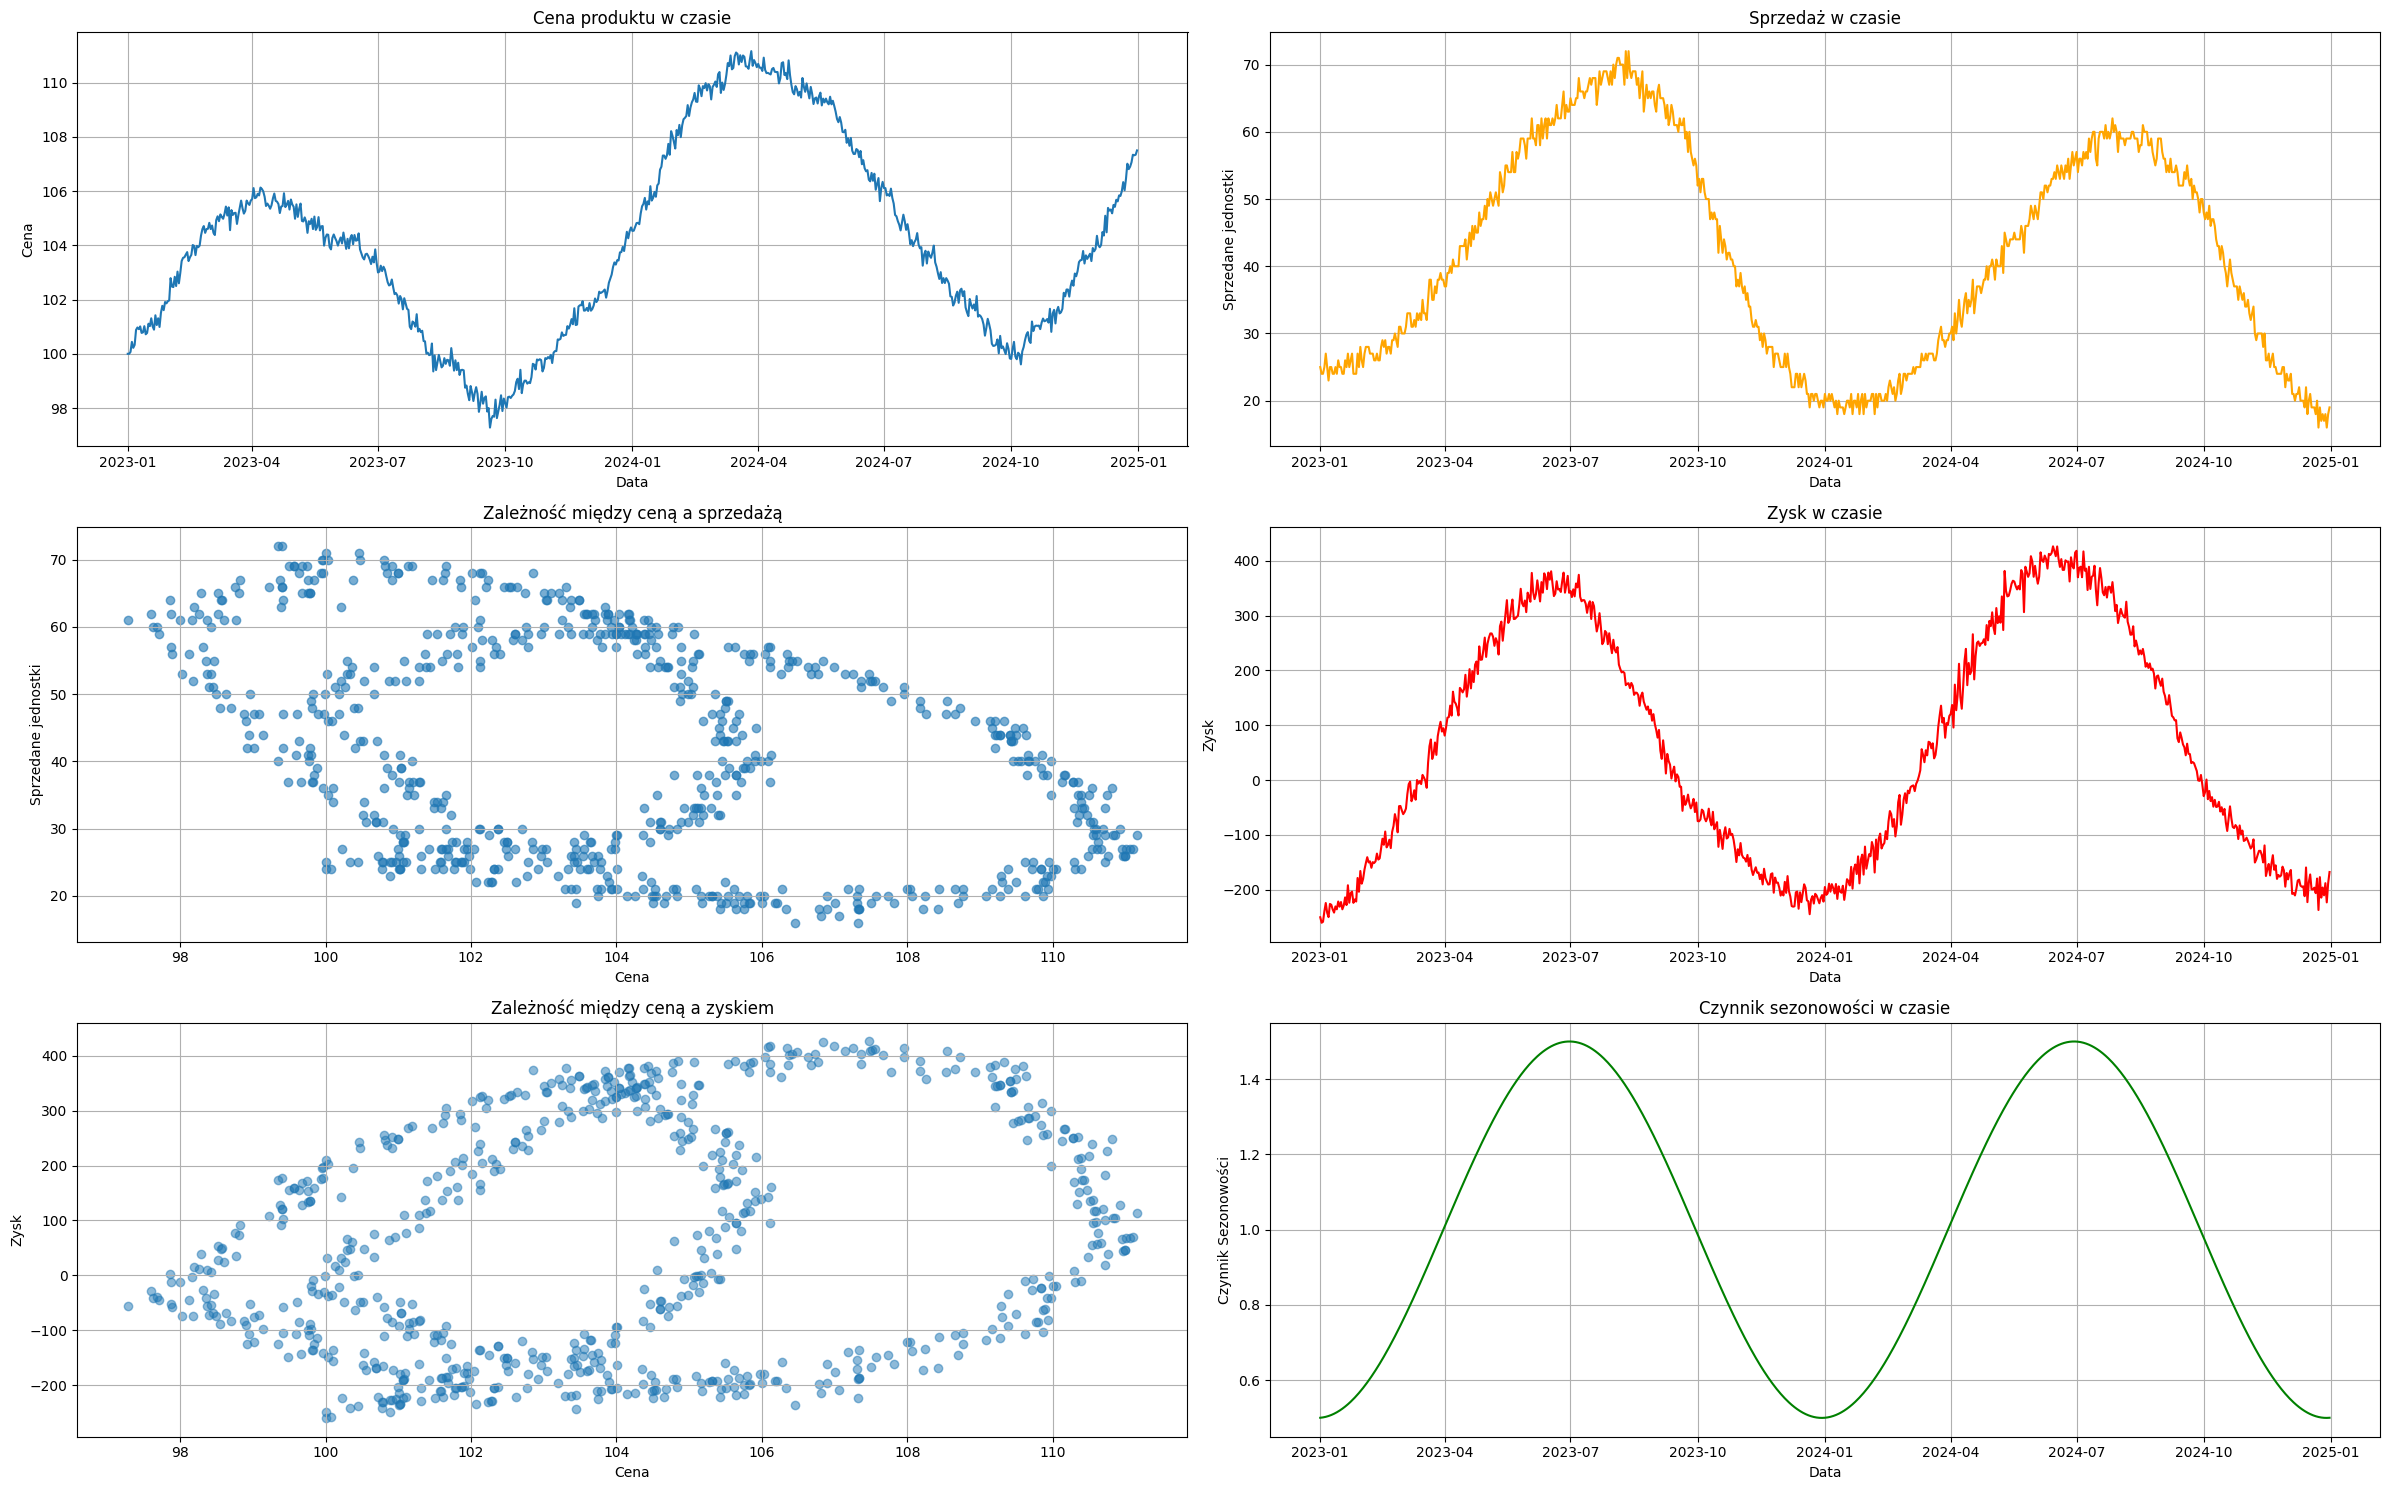

Średnia cena: 104.03
Średnia sprzedaż: 41.58
Suma zysków: 45609.26


In [21]:
# Ustawienia symulacji
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

# Parametry bazowe
baseline_price = 100           # bazowa cena produktu
baseline_demand = 50           # bazowa liczba sprzedanych jednostek
elasticity = 5.0               # parametr elastyczności cenowej
seasonal_amplitude = 0.5       # amplituda sezonowości (np. 50% wzrostu/spadku popytu)
phase_shift = 90               # przesunięcie fazowe, aby sezonowość "właściwie" rozłożyła się w roku

# Parametry kosztowe
unit_cost = 90                 # koszt jednostkowy produktu – jeśli cena < unit_cost, generujemy stratę na każdej jednostce
fixed_cost = 500               # koszty stałe, które trzeba pokryć niezależnie od sprzedaży

# Funkcja do generowania zakresu dat
def generate_date_range(start, end):
    delta = end - start
    return [start + timedelta(days=i) for i in range(delta.days + 1)]

# Generowanie listy dat
dates = generate_date_range(start_date, end_date)

np.random.seed(42)  # Dla powtarzalności wyników
# Generowanie sygnału cenowego analogicznie do przykładu z temperaturą
time_index = np.arange(len(dates))
# Komponent cykliczny – np. zmiany o ~5% ceny bazowej w skali roku
price_cyclic = baseline_price * 0.05 * np.sin(2 * np.pi * time_index / 365)
# Szum losowy
price_noise = 0.2 * np.random.normal(size=len(dates))
# Trend niestabilności – kumulacja losowych zmian
price_trend = np.cumsum(np.random.normal(0, 0.1, size=len(dates)))
# Generowany sygnał cenowy
price_series = baseline_price + price_cyclic + price_noise + price_trend
price_series = np.round(price_series, 2)

data = []
for i, date in enumerate(dates):
    # Oblicz dzień roku
    day_of_year = date.timetuple().tm_yday
    
    # Sezonowy czynnik wpływający na popyt
    seasonal_factor = 1 + seasonal_amplitude * np.sin(2 * np.pi * (day_of_year - phase_shift) / 365)
    
    # Używamy wygenerowanego sygnału cenowego
    price = price_series[i]
    # Upewnij się, że cena nie jest ujemna
    price = max(0, price)
    
    # Modelowanie popytu: im wyższa cena, tym popyt spada (zależność elastyczna) + dodajemy szum
    demand = baseline_demand * seasonal_factor * (baseline_price / price) ** elasticity
    # np.random.normal zwraca liczbę losową, która jest próbą z rozkładu normalnego o średniej równej demand i odchyleniu standardowym równym 1
    demand = np.random.normal(loc=demand, scale=1)
    demand = max(0, int(round(demand)))
    
    # Obliczanie zysku: (cena - koszt jednostkowy) * sprzedane jednostki - koszty stałe
    profit = (price - unit_cost) * demand - fixed_cost
    
    data.append({
        'data': date,
        'cena': price,
        'sprzedane_jednostki': demand,
        'seasonal_factor':seasonal_factor,
        'zysk': profit
    })

# Tworzenie DataFrame
df = pd.DataFrame(data)

# Wizualizacja danych: układ 3x2 subplotów
fig, axs = plt.subplots(3, 2, figsize=(24, 15))

# Wykres 1: Cena produktu w czasie
axs[0, 0].plot(df['data'], df['cena'])
axs[0, 0].set_title("Cena produktu w czasie")
axs[0, 0].set_xlabel("Data")
axs[0, 0].set_ylabel("Cena")
axs[0, 0].grid(True)

# Wykres 2: Sprzedaż w czasie
axs[0, 1].plot(df['data'], df['sprzedane_jednostki'], color='orange')
axs[0, 1].set_title("Sprzedaż w czasie")
axs[0, 1].set_xlabel("Data")
axs[0, 1].set_ylabel("Sprzedane jednostki")
axs[0, 1].grid(True)

# Wykres 3: Zależność między ceną a sprzedażą
axs[1, 0].scatter(df['cena'], df['sprzedane_jednostki'], alpha=0.6)
axs[1, 0].set_title("Zależność między ceną a sprzedażą")
axs[1, 0].set_xlabel("Cena")
axs[1, 0].set_ylabel("Sprzedane jednostki")
axs[1, 0].grid(True)

# Wykres 4: Zysk w czasie
axs[1, 1].plot(df['data'], df['zysk'], color='red')
axs[1, 1].set_title("Zysk w czasie")
axs[1, 1].set_xlabel("Data")
axs[1, 1].set_ylabel("Zysk")
axs[1, 1].grid(True)

# Wykres 5: Zależność między ceną a zyskiem
axs[2, 0].scatter(df['cena'], df['zysk'], alpha=0.5)
axs[2, 0].set_title("Zależność między ceną a zyskiem")
axs[2, 0].set_xlabel("Cena")
axs[2, 0].set_ylabel("Zysk")
axs[2, 0].grid(True)

# Wykres 6: Sezonowość – wykres sezonowego czynnika w czasie
axs[2, 1].plot(df['data'], df['seasonal_factor'], color='green')
axs[2, 1].set_title("Czynnik sezonowości w czasie")
axs[2, 1].set_xlabel("Data")
axs[2, 1].set_ylabel("Czynnik Sezonowości")
axs[2, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Średnia cena: {round(df['cena'].mean(), 2)}")
print(f"Średnia sprzedaż: {round(df['sprzedane_jednostki'].mean(), 2)}")
print(f"Suma zysków: {df['zysk'].sum()}")



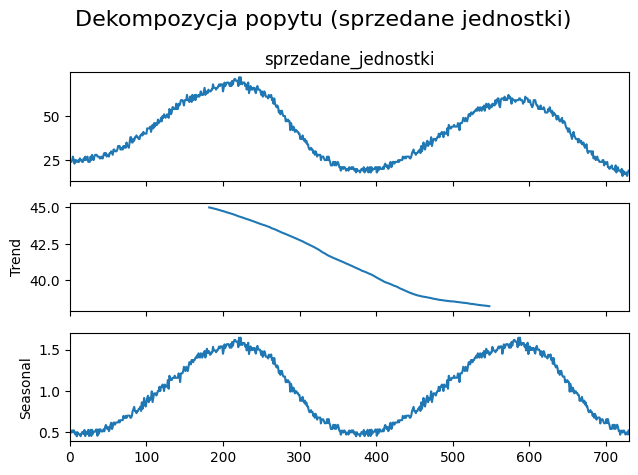

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Dekompozycja szeregu czasowego dla popytu (sprzedanych jednostek)
decomp_demand = seasonal_decompose(df['sprzedane_jednostki'], model='multiplicative', period=365)
fig1 = decomp_demand.plot(resid=False)
fig1.suptitle("Dekompozycja popytu (sprzedane jednostki)", fontsize=16)
plt.tight_layout()
plt.show()


In [4]:
df.to_csv(f"sell_data.csv", index=False)

In [5]:
df

,data,cena,sprzedane_jednostki,seasonal_factor,zysk
0,2023-01-01,100.00,25,0.500375,-250.00
1,2023-01-02,100.00,24,0.500782,-260.00
2,2023-01-03,100.07,24,0.501338,-258.32
3,2023-01-04,100.44,25,0.502041,-239.00
4,2023-01-05,100.22,27,0.502891,-224.06
...,...,...,...,...,...
726,2024-12-27,107.06,17,0.500227,-209.98
727,2024-12-28,107.34,18,0.500042,-187.88
728,2024-12-29,107.32,16,0.500005,-222.88
729,2024-12-30,107.34,18,0.500116,-187.88


In [6]:
df.isnull().sum()

data                   0
cena                   0
sprzedane_jednostki    0
seasonal_factor        0
zysk                   0
dtype: int64

In [7]:
df.describe()

,data,cena,sprzedane_jednostki,seasonal_factor,zysk
count,731,731.000000,731.000000,731.000000,731.000000
mean,2024-01-01 00:00:00,104.034295,41.580027,0.999317,62.392969
min,2023-01-01 00:00:00,97.280000,16.000000,0.500005,-260.000000
25%,2023-07-02 12:00:00,101.170000,26.500000,0.645690,-138.905000
50%,2024-01-01 00:00:00,103.890000,40.000000,1.000000,38.650000
75%,2024-07-01 12:00:00,105.980000,56.000000,1.352792,265.840000
max,2024-12-31 00:00:00,111.160000,72.000000,1.499995,426.440000
std,NaN,3.494650,15.979613,0.354036,210.904446


### Reinforcement Learning - DQN

Używamy Deep Q Network (DQN). DQN to algorytm uczenia ze wzmocnieniem, który wykorzystuje głęboką sieć neuronową do przybliżenia optymalnej funkcji wartości Q. Gromadzi doświadczenia z interakcji ze środowiskiem i przechowuje je w buforze powtórek, który służy do próbkowania mini-partii do treningu. Oddzielna sieć docelowa jest utrzymywana w celu zapewnienia stabilnych docelowych wartości Q podczas uczenia. Podejście to okazało się skuteczne w rozwiązywaniu zadań wielowymiarowych, takich jak nauka grania w gry Atari (publikacja algorytmu DQN - 2013).

### Strategia Dynamicznego Ustalania Cen z Uczeniem przez Wzmacnianie

Główne idee rozwiązania można przedstawić następująco:

### 1. Symulacja Rynku i Popytu

- **Środowisko symulacji** odwzorowuje proces sprzedaży przy zadanej polityce cenowej.
- **Agent** rozpoczyna od określonej ceny, a następnie, w każdym kroku, decyduje o zmianie ceny w określonym zakresie.
- **Wpływ ceny na popyt**: Nowa cena wpływa na wielkość popytu – symulowaną przy użyciu modelu popytu, który uwzględnia:
  - Czynniki sezonowe,
  - Elastyczność cenową,
  - Elementy losowe, nadające dynamikę procesowi sprzedaży.

### 2. Obliczanie Nagrody

- Na podstawie wybranej ceny oraz uzyskanej liczby sprzedanych jednostek, środowisko oblicza **nagrodę**.
- **Nagroda** stanowi zysk osiągnięty w danym kroku (przychód minus koszty) i jest kluczowym sygnałem informacyjnym dla agenta uczącego się, jakie decyzje cenowe prowadzą do lepszych wyników finansowych.

### 3. Reprezentacja Stanu z Historią

- Aby agent mógł lepiej wychwycić trend oraz zmienność rynku, stan środowiska zawiera:
  - Aktualne dane (np. bieżącą cenę, sprzedaż, zysk),
  - Okno historyczne (lista ostatnich kroków).
- Dzięki temu agent ma dostęp do krótkoterminowej historii, co umożliwia podejmowanie bardziej świadomych decyzji.

### 4. Trening Agenta przy Użyciu DQN

- W rozwiązaniu zastosowano algorytm **Deep Q-Network (DQN)**, który uczy się przybliżać funkcję wartości Q.
- Agent eksploruje środowisko, podejmując decyzje cenowe, a następnie na podstawie otrzymywanych nagród koryguje swoje zachowanie.
- Proces uczenia odbywa się na danych historycznych, podzielonych na część **treningową** i **testową**, co pozwala na ocenę skuteczności wyuczonej polityki.

### 5. Proces Iteracyjny Uczenia i Testowania

### Faza Treningowa

- Agent przetwarza sekwencję decyzji cenowych.
- Środowisko zwraca stany, nagrody oraz informację o zakończeniu epizodu.
- Dzięki temu agent może systematycznie poprawiać swoje decyzje.

### Faza Testowa

- Po zakończeniu treningu agent testowany jest na oddzielnym zbiorze danych.
- Model podejmuje decyzje, a środowisko symuluje rynek, umożliwiając ocenę, jak wyuczona polityka radzi sobie w nowych warunkach.


### Parametry Modelu DQN

**learning_rate** (0.001)
- **Opis:** Określa tempo uczenia się modelu. 
- **Znaczenie:** Mówi o tym, jak duży krok wykonuje optymalizator przy aktualizacji wag sieci.
- **Uwagi:** Zbyt duża wartość może powodować niestabilne uczenie się, a zbyt mała – wolną konwergencję.

**buffer_size** (500000)
- **Opis:** Rozmiar bufora pamięci replay.
- **Znaczenie:** Przechowywane są tam doświadczenia (stany, akcje, nagrody, kolejne stany).
- **Uwagi:** Większy bufor umożliwia większą różnorodność próbek, ale wymaga więcej pamięci i może spowolnić proces uczenia.

**learning_starts** (100)
- **Opis:** Liczba kroków wymaganych przed rozpoczęciem aktualizacji parametrów modelu.
- **Znaczenie:** Na początku model zbiera dane, co może pomóc w stabilniejszym uczeniu się.

**batch_size** (256)
- **Opis:** Liczba próbek pobieranych z bufora w jednym kroku uczenia.
- **Znaczenie:** Większe batch_size mogą prowadzić do bardziej stabilnych aktualizacji.
- **Uwagi:** Większe wartości wymagają więcej zasobów obliczeniowych.

**gamma** (0.99)
- **Opis:** Współczynnik dyskontowy.
- **Znaczenie:** Określa, jak bardzo przyszłe nagrody są brane pod uwagę.
- **Uwagi:** Wartość bliska 1 oznacza, że przyszłe nagrody mają niemal taką samą wartość jak nagrody natychmiastowe, co jest istotne w problemach, gdzie decyzje mają długoterminowe skutki.

**train_freq** (1)
- **Opis:** Częstotliwość, z jaką model przeprowadza proces uczenia się.
- **Znaczenie:** Wartość 1 oznacza, że uczenie odbywa się po każdym kroku interakcji z otoczeniem.

**verbose** (0)
- **Opis:** Poziom szczegółowości wypisywanych logów.
- **Znaczenie:** Ustawienie na 0 wyłącza komunikaty.
- **Uwagi:** Może być przydatne, gdy zależy nam na czystości konsoli.


In [8]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN

class DynamicPricingEnv(gym.Env):
    def __init__(self, data, window_size=5, delta=10):
        super(DynamicPricingEnv, self).__init__()
        self.data = data.reset_index(drop=True)
        self.current_step = 1
        self.window_size = window_size
        
        # Zakres cenowy
        self.min_price, self.max_price = 70, 200
        self.delta = delta  # maksymalna zmiana ceny w górę lub w dół
        
        # Dyskretyzujemy przestrzeń akcji: zakres zmian od -delta do +delta
        self.num_actions = 2 * self.delta + 1  # np. dla delta=10 mamy 21 możliwych akcji
        self.action_space = spaces.Discrete(self.num_actions)
        
        # Każdy stan ma 4 cechy: [prev_price, current_price, sprzedane jednostki, zysk]
        low_state = np.array([0, 0, 0, -np.inf])
        high_state = np.array([200, 200, np.inf, np.inf])
        self.observation_space = spaces.Box(
            low=np.tile(low_state, window_size),
            high=np.tile(high_state, window_size),
            dtype=np.float64
        )
        self.history = []  # bufor do przechowywania historii stanów

        # Atrybuty do logowania wyników
        self.revenues = []
        self.prices = []
        self.units = []
        
        # Zmienne do agregacji wyników epizodów
        self.episode_rewards = []         # lista sumarycznych nagród epizodowych
        self.current_episode_reward = 0   # bieżąca suma nagród w epizodzie

        self.last_price = self.data.iloc[0]['cena']  # inicjalizacja

    def step(self, action):
        # Mapowanie akcji dyskretnej na przesunięcie ceny
        # Dyskretna akcja (liczba całkowita z zakresu [0, 2*delta]) reprezentuje przesunięcie ceny:
        # Aby uzyskać przesunięcie (zmianę ceny) w zakresie [-delta, +delta], odejmujemy od akcji wartość delta.
        price_change = action - self.delta
        # Nowa cena to poprzednia cena powiększona o przesunięcie, ale ograniczona do [min_price, max_price]
        new_price = self.last_price + price_change
        new_price = np.clip(new_price, self.min_price, self.max_price)
        
        seasonal_factor = self.data.iloc[self.current_step]['seasonal_factor']
        
        # Obliczenie liczby sprzedanych jednostek na podstawie funkcji popytu
        sold_units = baseline_demand * seasonal_factor * (baseline_price / new_price) ** elasticity
        # np.random.normal zwraca liczbę losową, która jest próbą z rozkładu normalnego o średniej równej sold_units i odchyleniu standardowym równym 1
        sold_units = np.random.normal(loc=sold_units, scale=1)
        sold_units = max(0, int(round(sold_units)))
        
        # Funkcja nagrody
        reward = (new_price - unit_cost) * sold_units - fixed_cost

        # Akumulacja nagrody dla bieżącego epizodu
        self.current_episode_reward += reward

        # Przygotowanie bieżącego stanu
        current_state = np.array([self.last_price, new_price, sold_units, reward])
        
        # Aktualizacja ostatniej ceny
        self.last_price = new_price

        # Logowanie wartości
        self.revenues.append(reward)
        self.prices.append(new_price)
        self.units.append(sold_units)

        # Aktualizacja historii – uzupełnienie bufora, aby mieć zawsze window_size stanów
        self.history.append(current_state)
        if len(self.history) < self.window_size:
            padded_history = [self.history[0]] * (self.window_size - len(self.history)) + self.history
        else:
            padded_history = self.history[-self.window_size:]
        
        # next_state to konkatenacja (łączenie) poszczególnych stanów z bufora
        # Dzięki temu agent widzi sekwencję stanów (o długości window_size), co może pomóc w identyfikacji trendów.
        next_state = np.concatenate(padded_history)
        
        self.current_step += 1
        terminated = self.current_step >= len(self.data) - 1

        # Jeśli epizod się kończy, zapisujemy skumulowaną nagrodę i zerujemy stan obserwacji
        if terminated:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0
            next_state = np.zeros(self.observation_space.shape)
        
        return next_state, reward, terminated, False, {}
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Resetujemy sumę nagród tylko wtedy, gdy poprzedni epizod się zakończył
        if self.current_step < len(self.data):  
            if self.current_episode_reward != 0:
                self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0

        self.current_step = 1
        
        # Inicjalizacja stanu początkowego pobranego z pierwszego wiersza danych
        initial_price = self.data.iloc[0]['cena']
        initial_state = np.array([
            initial_price,  # prev_price
            initial_price,  # current_price
            self.data.iloc[0]['sprzedane_jednostki'],
            self.data.iloc[0]['zysk']
        ])
        
        # Wypełniamy bufor stanów
        self.history = [initial_state] * self.window_size
        self.last_price = initial_price
        
        # Resetujemy logi
        self.revenues = []
        self.prices = []
        self.units = []
        
        obs = np.concatenate(self.history)
        return obs, {}

# Ładowanie danych
data = pd.read_csv('sell_data.csv')
train_size = int(len(data) * 0.5)
train_data, test_data = data[:train_size], data[train_size:]


### Definicja hiperparametrów modelu DQN

In [ ]:

dqn_params = {
    "learning_rate": 0.00005,
    "buffer_size": 1000000,
    "learning_starts": 100,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 1,
    "verbose": 0,
}


### Funkcja do nauczania modelu i funckja do wyświetlania wyników

In [ ]:
def Learnings_Run(dqn_params, train_data, test_data, window_size, epochs_number, delta = 15):
    # Inicjalizacja środowisk treningowego i testowego
    train_env = DynamicPricingEnv(train_data, window_size=window_size, delta=delta)
    test_env  = DynamicPricingEnv(test_data, window_size=window_size, delta=delta)
    # Inicjalizacja i trenowanie modelu DQN
    model = DQN('MlpPolicy', train_env, **dqn_params)
    # Wyrównanie liczby timesteps żeby dostać jednakową liczbę kroków w poszczególnych epokach 
    # liczba kroków w epoce: total_timesteps // epochs_number = 362 dni (1 rok)
    total_timesteps = epochs_number * (len(train_data)-1) - epochs_number - 1 
    model.learn(total_timesteps=total_timesteps)
    
    return model, train_env, test_env

def Plot_Learning_Progress(train_env):
    # Postęp uczenia (sumaryczne nagrody epizodowe)
    plt.figure(figsize=(10,5))
    plt.plot(train_env.episode_rewards, marker='o')
    plt.xlabel("Numer epizodu")
    plt.ylabel("Suma nagród")
    plt.title("Postęp uczenia agenta")
    plt.grid(True)
    plt.show()

### Pierwszy trening

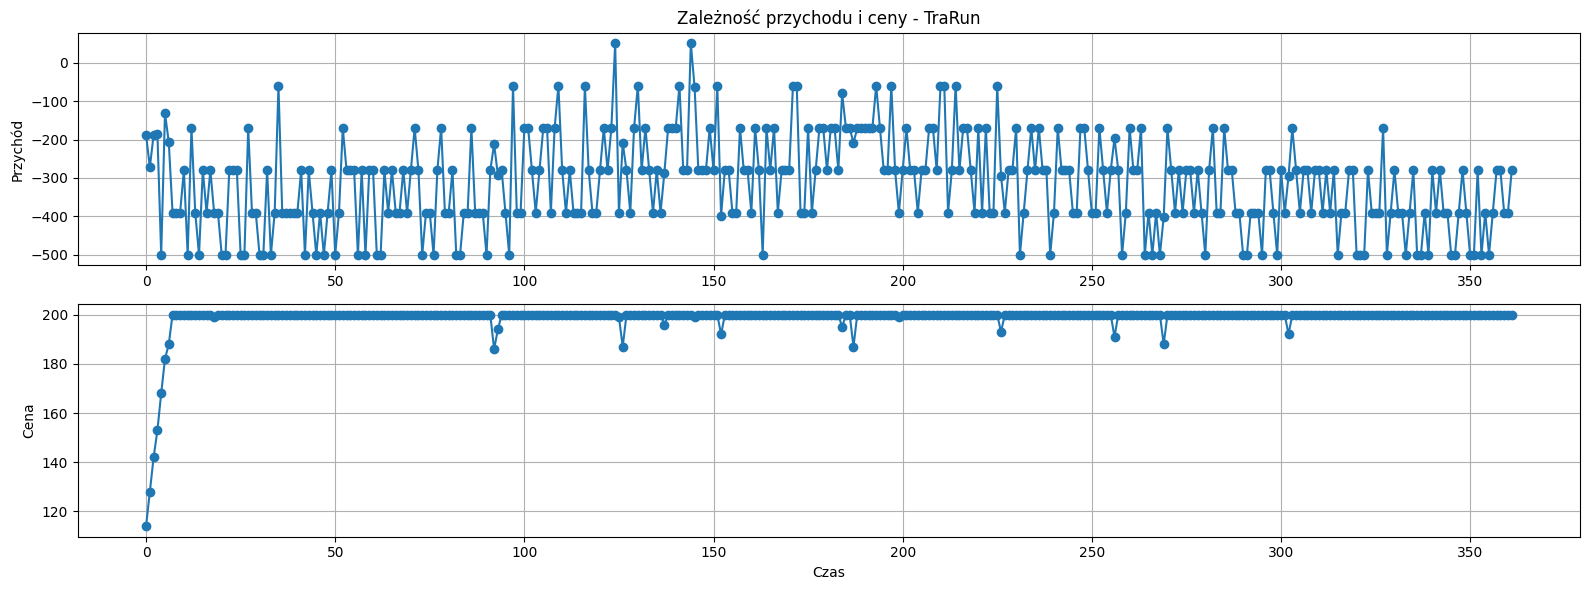

In [11]:
# Pierwszy Run
model, train_env, _ = Learnings_Run(dqn_params, train_data, test_data, window_size = 1, epochs_number = 50, delta = 15)

# Wizualizacja wyników Test
fig, axs = plt.subplots(2, 1, figsize=(16, 6))

# Wykres przychodu
axs[0].plot(train_env.revenues, marker='o')
axs[0].set_ylabel('Przychód')
axs[0].grid(True)
axs[0].set_title('Zależność przychodu i ceny - TrainRun')

# Wykres ceny
axs[1].plot(train_env.prices, marker='o')
axs[1].set_ylabel('Cena')
axs[1].set_xlabel('Czas')
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Dobór learning_rate

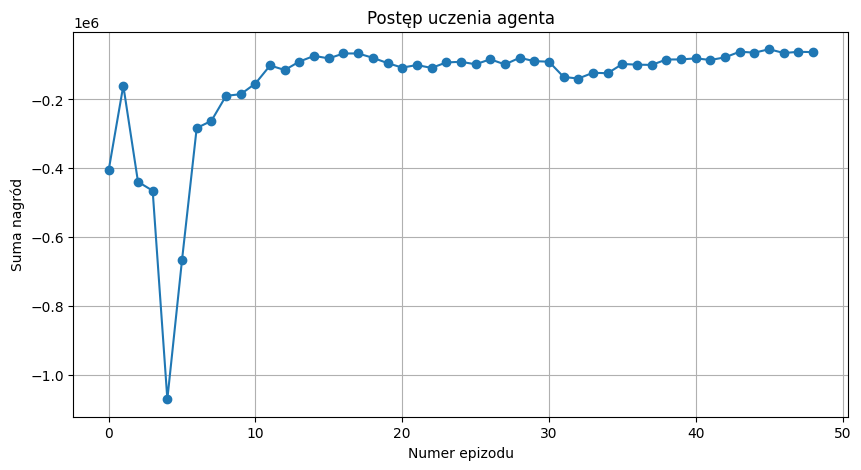

Średnia nagroda = -156608.0 | learning_rate = 1e-05


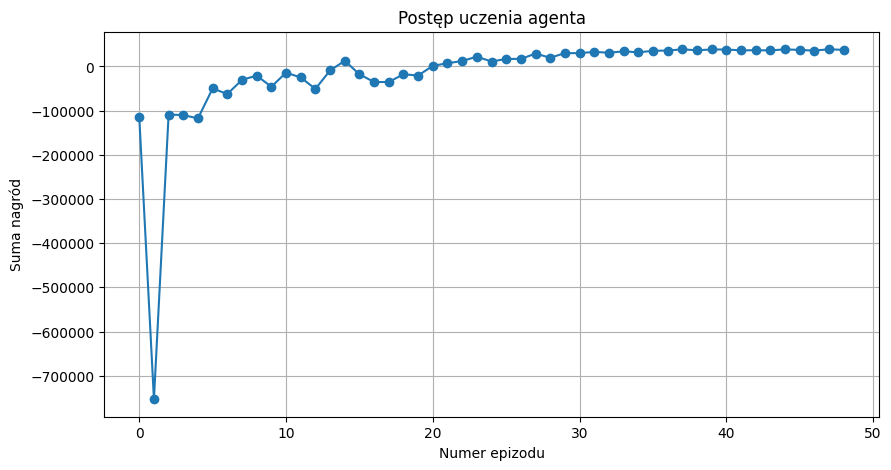

Średnia nagroda = -15827.0 | learning_rate = 5e-05


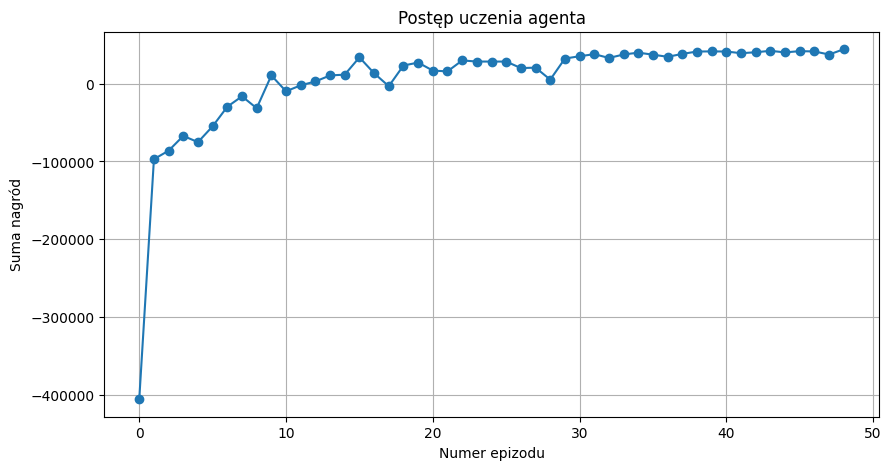

Średnia nagroda = 4663.0 | learning_rate = 0.0001
Najlepszy learning_rate: 0.0001 z średnią nagrodą: 4663.0


In [12]:
# Zmiana learning_rate
learning_rates = [0.00001, 0.00005, 0.0001]
average_reward = []

best_lr = None
best_reward = float('-inf')  # Początkowo bardzo mała wartość

for lr in learning_rates:
    dqn_params["learning_rate"] = lr
    model, train_env, test_env = Learnings_Run(dqn_params, train_data, test_data, window_size=10, epochs_number=50, delta=15)
    Plot_Learning_Progress(train_env)
    current_reward = sum(train_env.episode_rewards) // len(train_env.episode_rewards)
    average_reward.append(current_reward)
    print(f"Średnia nagroda = {current_reward} | learning_rate = {lr}")
    
    # Jeżeli obecny wynik jest lepszy, aktualizujemy best_lr oraz best_reward
    if current_reward > best_reward:
        best_reward = current_reward
        best_lr = lr

print(f"Najlepszy learning_rate: {best_lr} z średnią nagrodą: {best_reward}")


### Dobór gamma

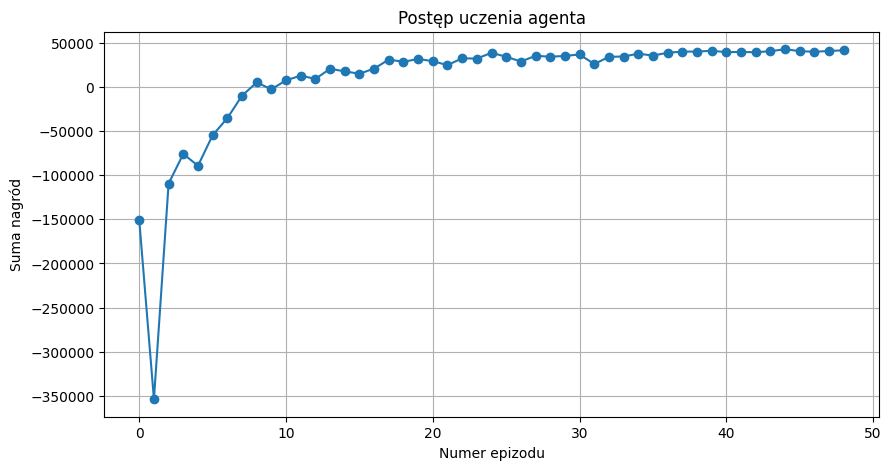

Średnia nagroda = 7809.0 | gamma = 0.05


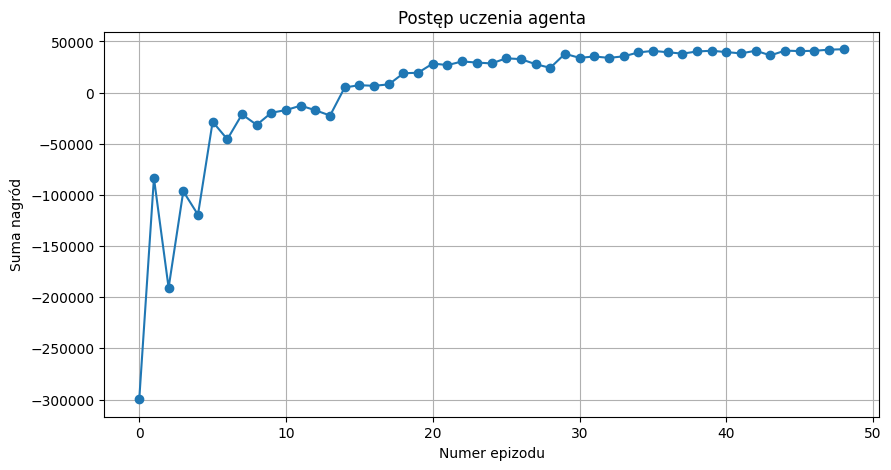

Średnia nagroda = 1993.0 | gamma = 0.75


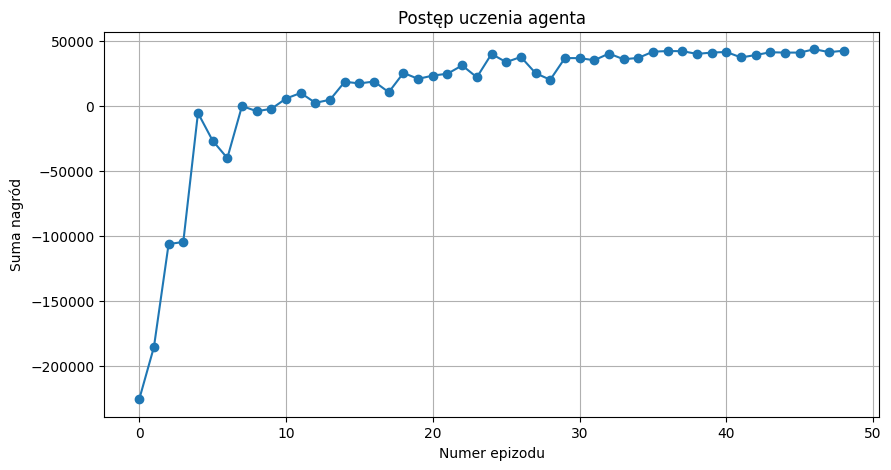

Średnia nagroda = 9713.0 | gamma = 0.99
Najlepsza gamma: 0.99 z średnią nagrodą: 9713.0


In [13]:
# Zmiana gamma
gammas = [0.05, 0.75, 0.99]
average_reward = []

best_ga = None
best_reward = float('-inf')  # Początkowo bardzo mała wartość

for ga in gammas:
    dqn_params["gamma"] = ga
    model, train_env, test_env = Learnings_Run(dqn_params, train_data, test_data, window_size=10, epochs_number=50, delta=15)
    Plot_Learning_Progress(train_env)
    current_reward = sum(train_env.episode_rewards) // len(train_env.episode_rewards)
    average_reward.append(current_reward)
    print(f"Średnia nagroda = {current_reward} | gamma = {ga}")
    
    # Jeżeli obecny wynik jest lepszy, aktualizujemy best_ga oraz best_reward
    if current_reward > best_reward:
        best_reward = current_reward
        best_ga = ga

print(f"Najlepsza gamma: {best_ga} z średnią nagrodą: {best_reward}")


### Dobór window_size

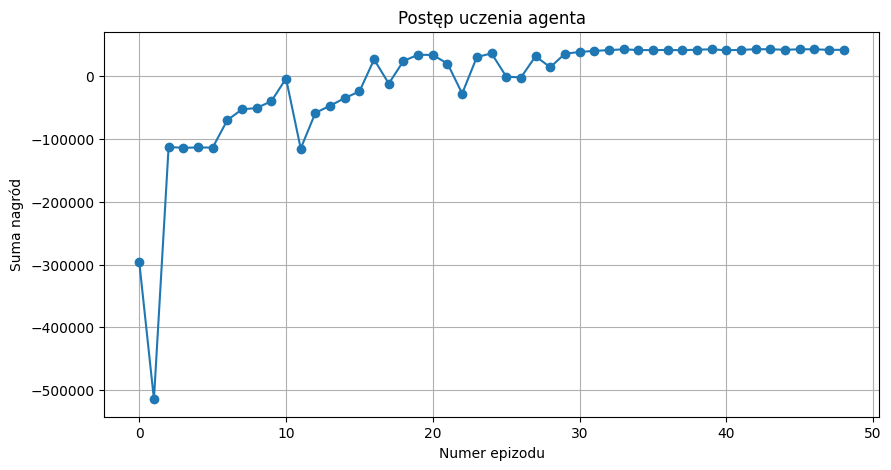

Średnia nagroda = -14623.0 | window = 1


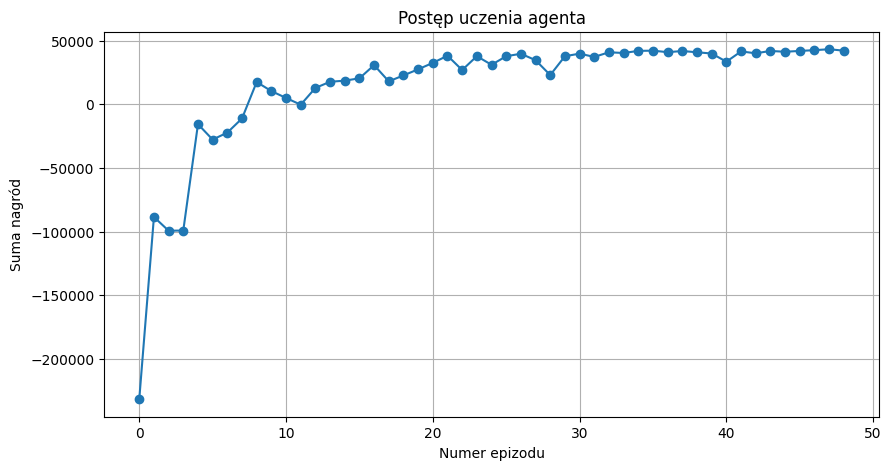

Średnia nagroda = 14657.0 | window = 10


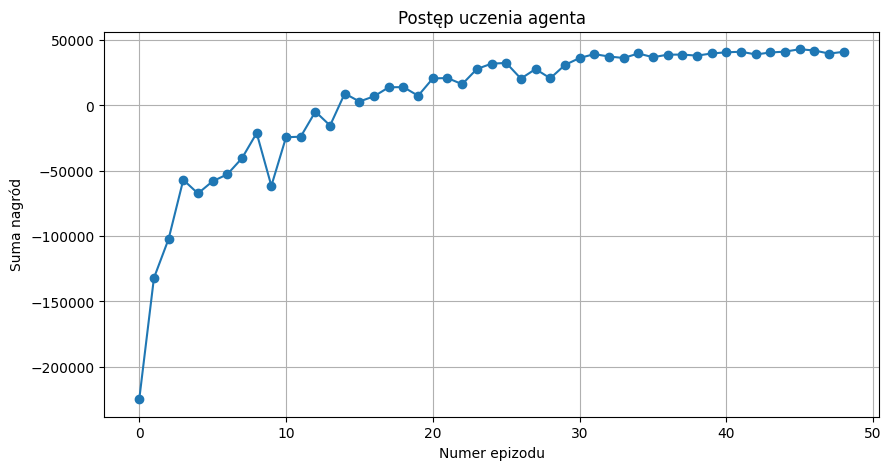

Średnia nagroda = 3492.0 | window = 25


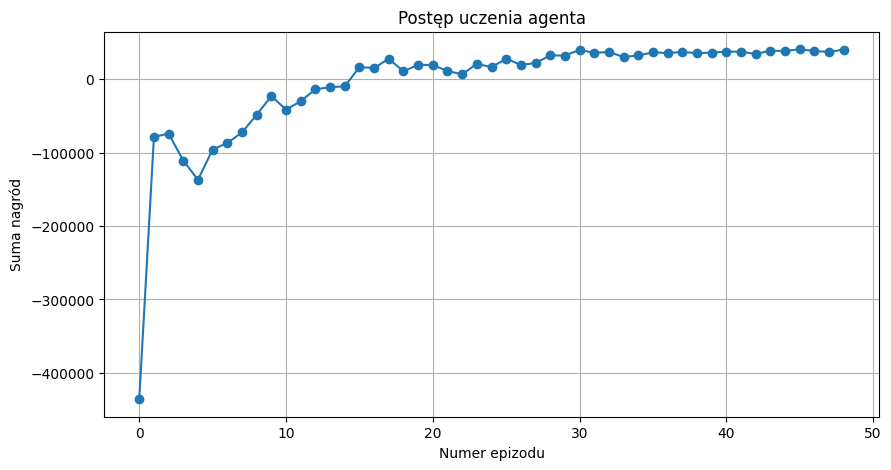

Średnia nagroda = -5598.0 | window = 50
Najlepsza gamma: 10 z średnią nagrodą: 14657.0


In [ ]:
# Zmiana window
windows = [1, 10, 25, 50]
average_reward = []

best_window = None
best_reward = float('-inf')  # Początkowo bardzo mała wartość

for wn in windows:
    model, train_env, test_env = Learnings_Run(dqn_params, train_data, test_data, window_size=wn, epochs_number=50, delta=15)
    Plot_Learning_Progress(train_env)
    current_reward = sum(train_env.episode_rewards) // len(train_env.episode_rewards)
    average_reward.append(current_reward)
    print(f"Średnia nagroda = {current_reward} | window = {wn}")
    
    # Jeżeli obecny wynik jest lepszy, aktualizujemy best_wn oraz best_reward
    if current_reward > best_reward:
        best_reward = current_reward
        best_wn = wn

print(f"Najlepsza gamma: {best_wn} z średnią nagrodą: {best_reward}")


### Trenowanie i Test z optymalnymi parametrami

In [15]:
dqn_params = {
    "learning_rate": best_lr,
    "buffer_size": 1000000,
    "learning_starts": 100,
    "batch_size": 32,
    "gamma": best_ga,
    "train_freq": 1,
    "verbose": 0,
}

epochs_number = 50

# Inicjalizacja środowisk treningowego i testowego
train_env = DynamicPricingEnv(train_data, window_size=best_wn, delta=15)
test_env  = DynamicPricingEnv(test_data, window_size=best_wn, delta=15)

# Inicjalizacja i trenowanie modelu DQN
model = DQN('MlpPolicy', train_env, **dqn_params)
# Wyrównanie liczby timesteps żeby dostać jednakową liczbę kroków w poszczególnych epokach 
# liczba kroków w epoce: total_timesteps // epochs_number = 362 dni (1 rok)
total_timesteps = epochs_number * (len(train_data)-1) - epochs_number - 1 
model.learn(total_timesteps=total_timesteps)

# Faza testowa
obs, _ = test_env.reset()
for _ in range(len(test_data) - 1):
    action, _ = model.predict(obs)
    obs, reward, terminated, _, _ = test_env.step(action)
    if terminated:
        break

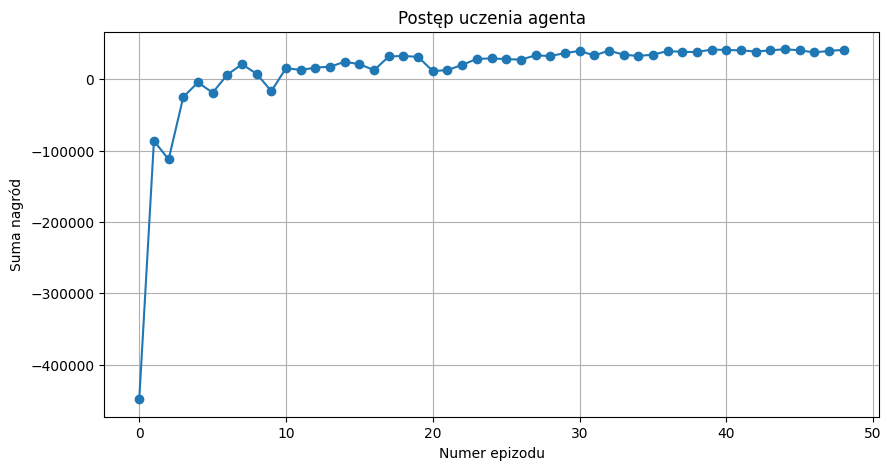

In [16]:
Plot_Learning_Progress(train_env)

### Metryki

In [17]:
from tabulate import tabulate

table = [
    ["Metryka", "Dane historyczne - okres treningowy", "Dane historyczne - okres testowy", "Faza treningowa", "Faza testowa"],
    ["Całkowity przychód",
     f"{train_data['zysk'].sum():.2f}",
     f"{test_data['zysk'].sum():.2f}",
     f"{sum(train_env.revenues):.2f}",
     f"{sum(test_env.revenues):.2f}"],
    
    ["Średnia cena",
     f"{test_data['cena'].mean():.2f}",
     f"{train_data['cena'].mean():.2f}",
     f"{np.mean(train_env.prices):.2f}",
     f"{np.mean(test_env.prices):.2f}"],
    
    ["Średnia sprzedaż (jednostki)",
     f"{test_data['sprzedane_jednostki'].mean():.2f}",
     f"{train_data['sprzedane_jednostki'].mean():.2f}",
     f"{np.mean(train_env.units):.2f}",
     f"{np.mean(test_env.units):.2f}"],
]

print(tabulate(table, headers="firstrow", tablefmt="fancy_grid"))


╒══════════════════════════════╤═══════════════════════════════════════╤════════════════════════════════════╤═══════════════════╤════════════════╕
│ Metryka                      │   Dane historyczne - okres treningowy │   Dane historyczne - okres testowy │   Faza treningowa │   Faza testowa │
╞══════════════════════════════╪═══════════════════════════════════════╪════════════════════════════════════╪═══════════════════╪════════════════╡
│ Całkowity przychód           │                              15079.9  │                           30529.3  │          41001    │       40588    │
├──────────────────────────────┼───────────────────────────────────────┼────────────────────────────────────┼───────────────────┼────────────────┤
│ Średnia cena                 │                                105.82 │                             102.25 │            114.2  │         112.92 │
├──────────────────────────────┼───────────────────────────────────────┼────────────────────────────────────┼─────────

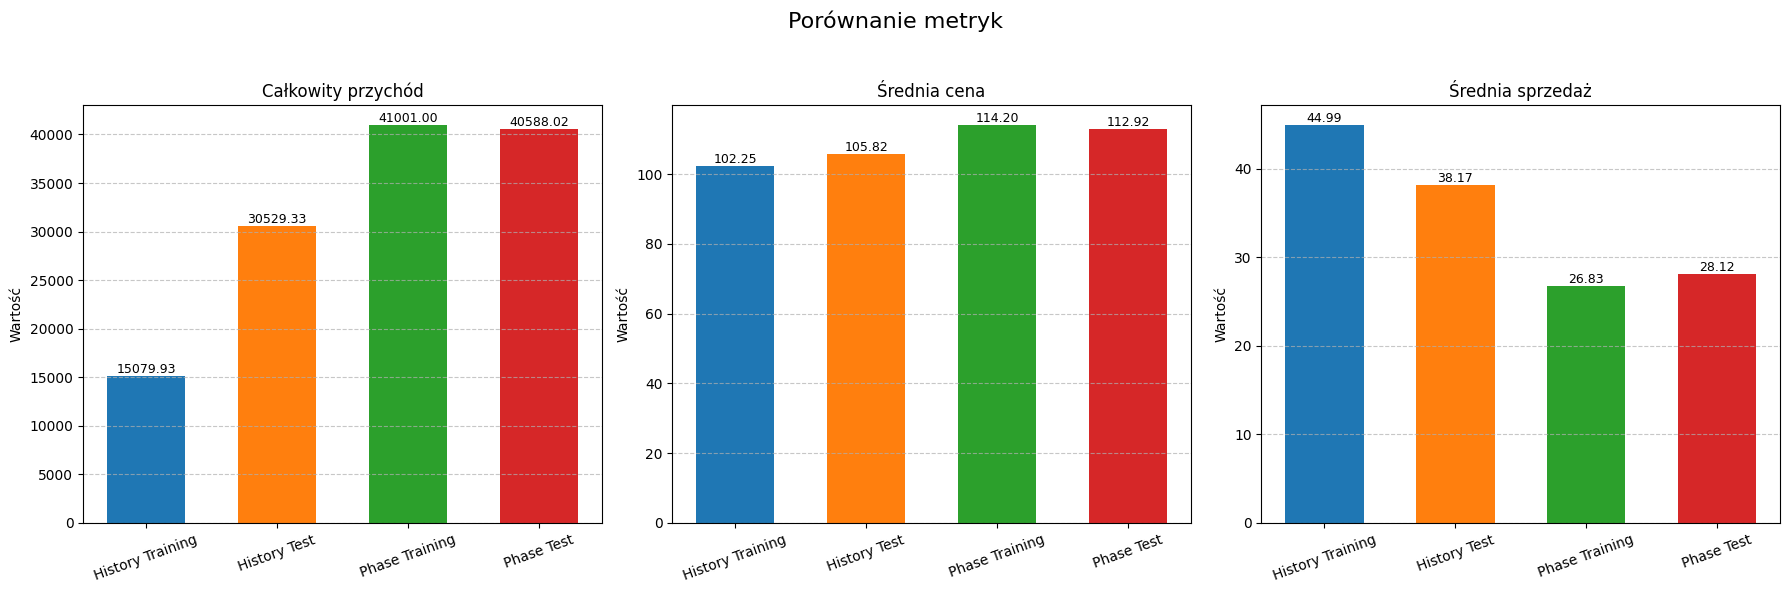

In [18]:
# Dane
metrics = ['Całkowity przychód', 'Średnia cena', 'Średnia sprzedaż']
historical_train = [train_data['zysk'].sum(), train_data['cena'].mean(), train_data['sprzedane_jednostki'].mean()]
historical_test  = [test_data['zysk'].sum(), test_data['cena'].mean(), test_data['sprzedane_jednostki'].mean()]
phase_train = [sum(train_env.revenues), np.mean(train_env.prices), np.mean(train_env.units)]
phase_test  = [sum(test_env.revenues), np.mean(test_env.prices), np.mean(test_env.units)]

categories = ['History Training', 'History Test', 'Phase Training', 'Phase Test']
all_data = [historical_train, historical_test, phase_train, phase_test]
x = np.arange(len(categories))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i, metric in enumerate(metrics):
    metric_values = [data[i] for data in all_data]
    bars = axes[i].bar(x, metric_values, width=0.6, color=colors)
    axes[i].set_title(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(categories, rotation=20)
    axes[i].set_ylabel('Wartość')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Dodajemy wartości nad słupkami
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
                     ha='center', va='bottom', fontsize=9)

fig.suptitle('Porównanie metryk', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


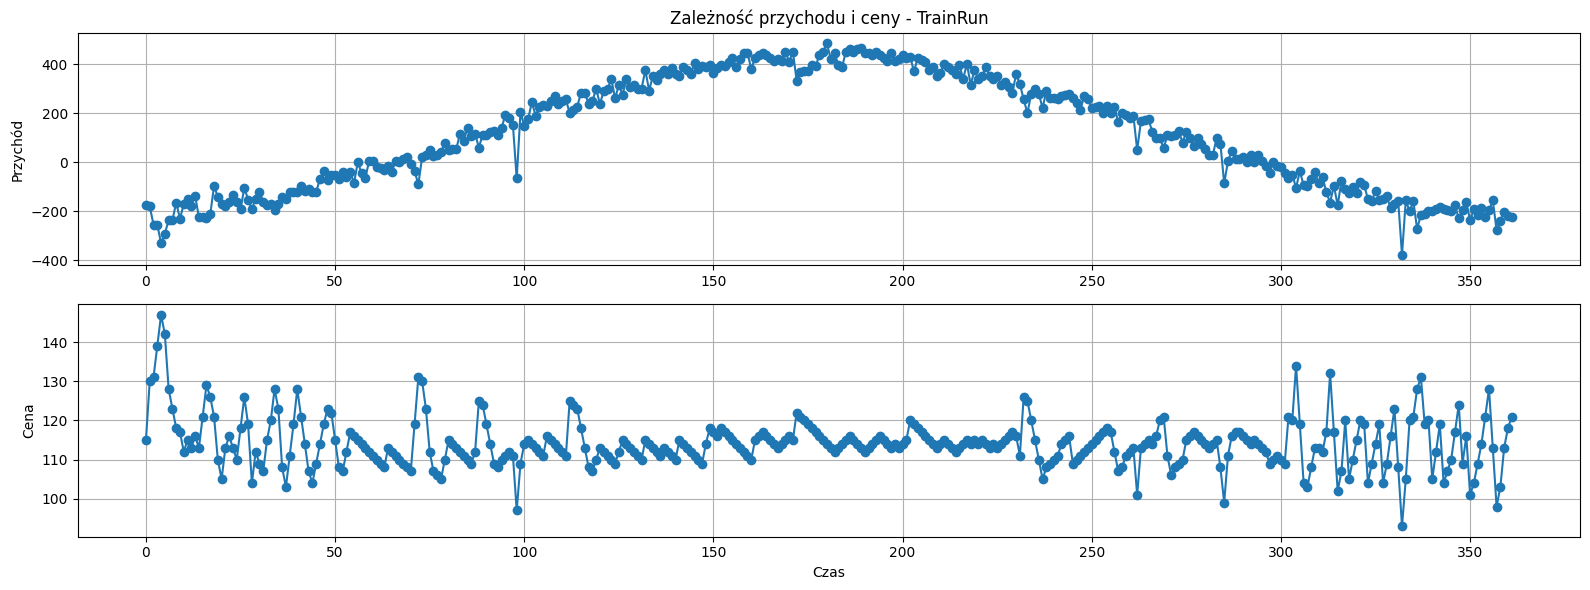

In [19]:
# Wizualizacja wyników Train
fig, axs = plt.subplots(2, 1, figsize=(16, 6))

# Wykres przychodu
axs[0].plot(train_env.revenues, marker='o')
axs[0].set_ylabel('Przychód')
axs[0].grid(True)
axs[0].set_title('Zależność przychodu i ceny - TrainRun')

# Wykres ceny
axs[1].plot(train_env.prices, marker='o')
axs[1].set_ylabel('Cena')
axs[1].set_xlabel('Czas')
axs[1].grid(True)

plt.tight_layout()
plt.show()


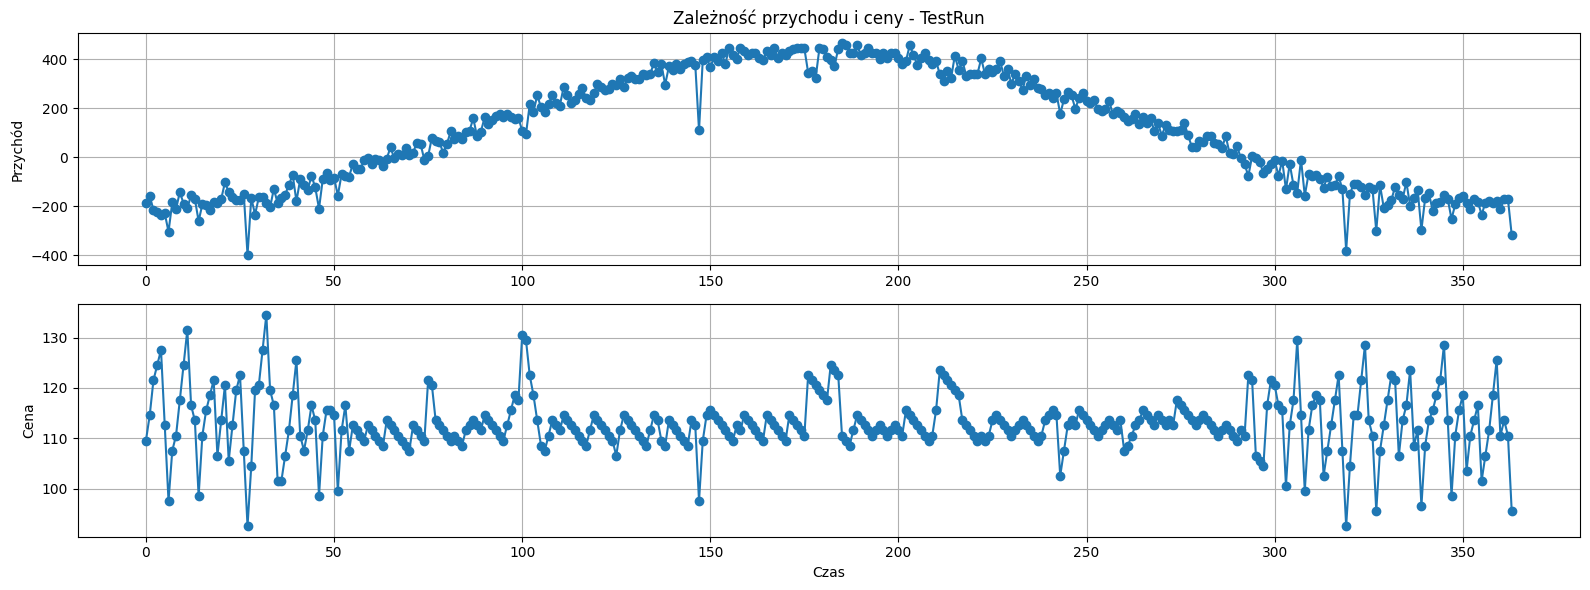

In [20]:
# Wizualizacja wyników Test
fig, axs = plt.subplots(2, 1, figsize=(16, 6))

# Wykres przychodu
axs[0].plot(test_env.revenues, marker='o')
axs[0].set_ylabel('Przychód')
axs[0].grid(True)
axs[0].set_title('Zależność przychodu i ceny - TestRun')

# Wykres ceny
axs[1].plot(test_env.prices, marker='o')
axs[1].set_ylabel('Cena')
axs[1].set_xlabel('Czas')
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Podsumowanie

Niniejsze badanie demonstruje skuteczne zastosowanie algorytmu Q-Learning w optymalizacji dynamicznych strategii cenowych dla sektorów detalicznych. Dzięki podejściu opartemu na uczeniu ze wzmocnieniem zaobserwowaliśmy poprawę elastyczności cenowej, dynamicznie dostosowując się do zmian warunków rynkowych i zachowań konsumentów. Wyniki potwierdzają, że uczenie ze wzmocnieniem nie tylko przewyższa tradycyjne metody badań operacyjnych pod względem generowania przychodów, ale także oferuje postępy w automatyzacji i udoskonalaniu decyzji cenowych. Ponadto, kluczowe znaczenie ma odpowiedni dobór hyperparametrów modelu oraz opracowanie skutecznego mechanizmu, według którego agent będzie podejmował decyzje dotyczące akcji, co dodatkowo zwiększa zdolność systemu do dynamicznego dostosowywania się do zmiennych warunków rynkowych.